## Step 1 - Install and Import Libraries

In [1]:
# Importing all the libraries we need
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

# For graphs and charts
import matplotlib.pyplot as plt
import seaborn as sns

# For building the ML model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Done! All libraries imported.")

Done! All libraries imported.


## Step 2 - Load the Dataset

In [2]:
# We need to upload the CSV file from our computer
from google.colab import files
uploaded = files.upload()  # A button will appear - click it and upload tmdb_5000_movies.csv

# Reading the CSV into a dataframe
df = pd.read_csv('tmdb_5000_movies.csv')

print("Dataset loaded!")
print("Number of movies:", len(df))
print("Columns:", list(df.columns))

Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv
Dataset loaded!
Number of movies: 4803
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


In [3]:
# Let's look at the first few rows
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## Step 3 - Clean the Data

The dataset has some issues:
- Some movies have budget or revenue as 0 (missing data)
- The genres column is in a special JSON format, we need to extract it

We fix all of this below.

In [4]:
# Remove movies where budget or revenue is 0 because those are incomplete entries
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
print("Movies remaining after removing 0 budget/revenue:", len(df))

Movies remaining after removing 0 budget/revenue: 3229


In [5]:
# The genres column looks like this: [{"id": 28, "name": "Action"}, ...]
# We need to extract just the genre names

def get_genres(text):
    try:
        genre_list = ast.literal_eval(text)
        names = [g['name'] for g in genre_list]
        return ', '.join(names)  # join them like "Action, Adventure"
    except:
        return ''

df['genre_names'] = df['genres'].apply(get_genres)

# Let's see what it looks like now
df[['title', 'genre_names']].head(5)

,title,genre_names
0,Avatar,"Action, Adventure, Fantasy, Science Fiction"
1,Pirates of the Caribbean: At World's End,"Adventure, Fantasy, Action"
2,Spectre,"Action, Adventure, Crime"
3,The Dark Knight Rises,"Action, Crime, Drama, Thriller"
4,John Carter,"Action, Adventure, Science Fiction"


In [6]:
# Create the target column - Hit (1) or Flop (0)
df['hit'] = (df['revenue'] >= 2 * df['budget']).astype(int)

# Check how many hits and flops we have
print("Hit (1) = Revenue >= 2x Budget")
print("Flop (0) = Revenue < 2x Budget")
print()
print(df['hit'].value_counts())

Hit (1) = Revenue >= 2x Budget
Flop (0) = Revenue < 2x Budget

hit
1    1809
0    1420
Name: count, dtype: int64


## Step 4 - Feature Engineering

We can't use the genre names directly in a model. We need to convert them into numbers.

We will create one column per genre, with 1 if the movie has that genre and 0 if it doesn't.
This is called **one-hot encoding** (or multi-hot encoding here since a movie can have multiple genres).

In [7]:
# List of genres we will use
genres_to_use = ['Action', 'Comedy', 'Drama', 'Horror',
                 'Romance', 'Thriller', 'Animation', 'Adventure']

# Create a 0/1 column for each genre
for genre in genres_to_use:
    df['is_' + genre] = df['genre_names'].apply(
        lambda x: 1 if genre in x else 0
    )

# Also extract the release year from release_date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year.fillna(2000).astype(int)

print("New columns added!")
df[['title', 'is_Action', 'is_Comedy', 'is_Drama', 'release_year']].head(5)

New columns added!


,title,is_Action,is_Comedy,is_Drama,release_year
0,Avatar,1,0,0,2009
1,Pirates of the Caribbean: At World's End,1,0,0,2007
2,Spectre,1,0,0,2015
3,The Dark Knight Rises,1,0,1,2012
4,John Carter,1,0,0,2012


In [8]:
# Select the final features we will use to train our model
feature_columns = ['budget', 'popularity', 'runtime', 'vote_average',
                   'release_year',
                   'is_Action', 'is_Comedy', 'is_Drama', 'is_Horror',
                   'is_Romance', 'is_Thriller', 'is_Animation', 'is_Adventure']

# Drop rows with any missing values in our selected columns
df_clean = df[feature_columns + ['hit', 'title']].dropna()

print("Final dataset size:", len(df_clean))
print("Features used:", feature_columns)

Final dataset size: 3229
Features used: ['budget', 'popularity', 'runtime', 'vote_average', 'release_year', 'is_Action', 'is_Comedy', 'is_Drama', 'is_Horror', 'is_Romance', 'is_Thriller', 'is_Animation', 'is_Adventure']


## Step 5 - Exploratory Data Analysis (EDA)

Before building the model, let's explore the data visually.

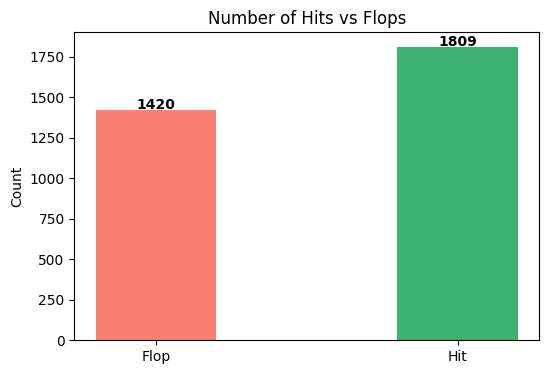

In [9]:
# Chart 1: How many hits vs flops?
plt.figure(figsize=(6, 4))
counts = df_clean['hit'].value_counts()
plt.bar(['Flop', 'Hit'], [counts[0], counts[1]], color=['salmon', 'mediumseagreen'], width=0.4)
plt.title('Number of Hits vs Flops')
plt.ylabel('Count')
plt.text(0, counts[0] + 5, str(counts[0]), ha='center', fontweight='bold')
plt.text(1, counts[1] + 5, str(counts[1]), ha='center', fontweight='bold')
plt.show()

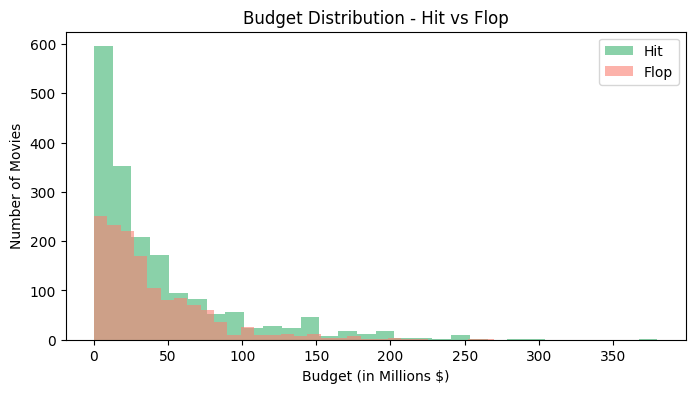

In [10]:
# Chart 2: Does higher budget mean more hits?
plt.figure(figsize=(8, 4))
plt.hist(df_clean[df_clean['hit'] == 1]['budget'] / 1e6, bins=30,
         alpha=0.6, color='mediumseagreen', label='Hit')
plt.hist(df_clean[df_clean['hit'] == 0]['budget'] / 1e6, bins=30,
         alpha=0.6, color='salmon', label='Flop')
plt.xlabel('Budget (in Millions $)')
plt.ylabel('Number of Movies')
plt.title('Budget Distribution - Hit vs Flop')
plt.legend()
plt.show()

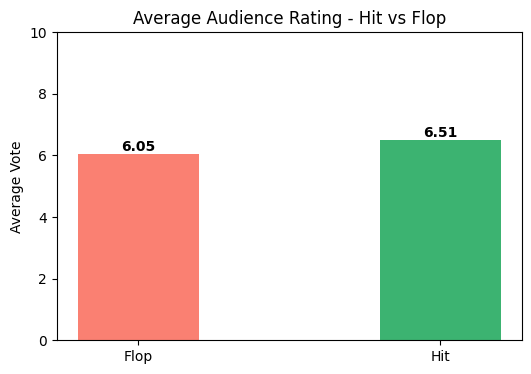

In [11]:
# Chart 3: Average rating of hits vs flops
avg_rating = df_clean.groupby('hit')['vote_average'].mean()
plt.figure(figsize=(6, 4))
plt.bar(['Flop', 'Hit'], [avg_rating[0], avg_rating[1]],
        color=['salmon', 'mediumseagreen'], width=0.4)
plt.title('Average Audience Rating - Hit vs Flop')
plt.ylabel('Average Vote')
plt.ylim(0, 10)
for i, v in enumerate([avg_rating[0], avg_rating[1]]):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')
plt.show()

## Step 6 - Train the Model

We will try two models:
1. **Logistic Regression** - a simple and commonly used classification algorithm
2. **Random Forest** - a more powerful model that uses multiple decision trees

In [12]:
# Separate features (X) and target (y)
X = df_clean[feature_columns]
y = df_clean['hit']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 2583
Testing samples : 646


In [13]:
# Scale the features - brings all values to a similar range
# This is important especially for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [14]:
# Train Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 73.07 %


In [15]:
# Train Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_predictions = rf_model.predict(X_test_scaled)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 73.68 %


## Step 7 - Evaluate the Models

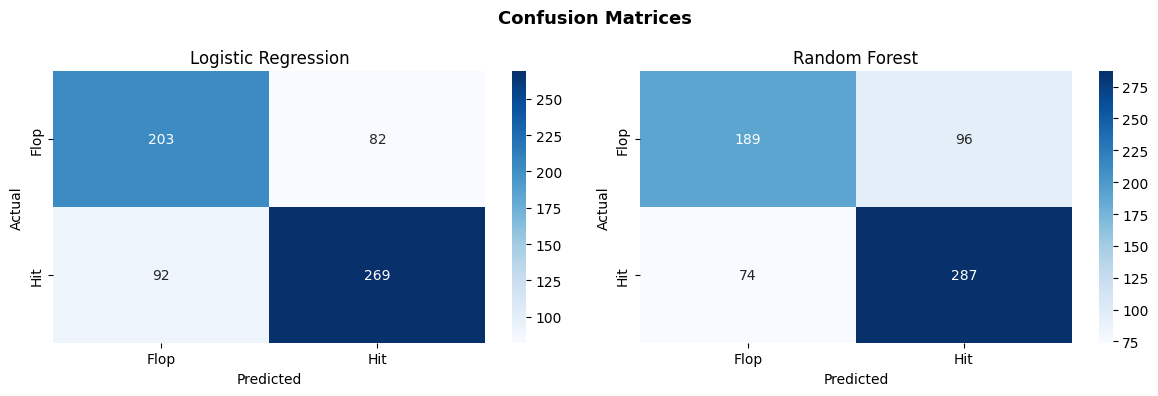


The confusion matrix shows:
- Top-left: Correctly predicted Flops
- Bottom-right: Correctly predicted Hits
- Top-right and Bottom-left: Wrong predictions


In [16]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model_name, preds in zip(axes,
                                  ['Logistic Regression', 'Random Forest'],
                                  [lr_predictions, rf_predictions]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Flop', 'Hit'],
                yticklabels=['Flop', 'Hit'])
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nThe confusion matrix shows:")
print("- Top-left: Correctly predicted Flops")
print("- Bottom-right: Correctly predicted Hits")
print("- Top-right and Bottom-left: Wrong predictions")

In [17]:
# Classification Report for Random Forest (our better model)
print("Detailed Report - Random Forest:")
print(classification_report(y_test, rf_predictions, target_names=['Flop', 'Hit']))

Detailed Report - Random Forest:
              precision    recall  f1-score   support

        Flop       0.72      0.66      0.69       285
         Hit       0.75      0.80      0.77       361

    accuracy                           0.74       646
   macro avg       0.73      0.73      0.73       646
weighted avg       0.74      0.74      0.74       646



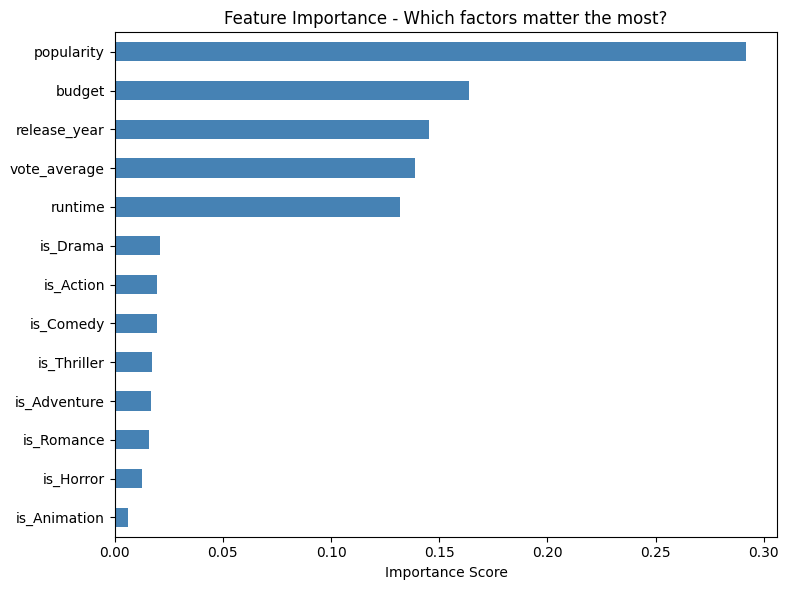

In [18]:
# Which features are most important according to Random Forest?
feature_importance = pd.Series(rf_model.feature_importances_, index=feature_columns)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feature_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Which factors matter the most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 8 - Predict a New Movie

Now that the model is trained, we can use it to predict any movie we want.
Just change the values below and run the cell.

In [19]:
# ---- CHANGE THESE VALUES ----
movie_budget     = 50000000   # budget in dollars (50 million = 50000000)
movie_popularity = 80         # popularity score (check TMDB for reference)
movie_runtime    = 120        # runtime in minutes
movie_rating     = 7.5        # expected audience rating out of 10
movie_year       = 2024       # release year

# Genre - set 1 if the movie belongs to that genre, 0 if not
is_Action    = 1
is_Comedy    = 0
is_Drama     = 0
is_Horror    = 0
is_Romance   = 0
is_Thriller  = 1
is_Animation = 0
is_Adventure = 1
# ------------------------------

# Put all values together in the correct order
new_movie = [[
    movie_budget,
    movie_popularity,
    movie_runtime,
    movie_rating,
    movie_year,
    is_Action, is_Comedy, is_Drama, is_Horror,
    is_Romance, is_Thriller, is_Animation, is_Adventure
]]

# Scale the input using the same scaler we trained on
new_movie_scaled = scaler.transform(new_movie)

# Get the prediction
prediction = rf_model.predict(new_movie_scaled)[0]
probability = rf_model.predict_proba(new_movie_scaled)[0]

hit_chance  = round(probability[1] * 100, 1)
flop_chance = round(probability[0] * 100, 1)

# Show the result
print("==============================")
if prediction == 1:
    print("Prediction: HIT")
else:
    print("Prediction: FLOP")
print(f"Hit  chance : {hit_chance}%")
print(f"Flop chance : {flop_chance}%")
print("==============================")

Prediction: HIT
Hit  chance : 93.0%
Flop chance : 7.0%
